In [1]:
import numpy as np

In [2]:
class environment:
    def __init__(self, grid_height, grid_width):
        self.height = grid_height
        self.width = grid_width
        self.start = []
        self.end = []
        self.reward = []
        self.map = np.array([i for i in range(grid_height * grid_width)])
        self.action_space = [0,1,2,3]
    def get_Map(self):
        print(self.map.reshape([self.width, self.height]))
    def get_NumState(self):
        return self.height * self.width
    def map_Designate(self, start_cell, end_cell, reward):
        self.start.append(start_cell)
        self.end.append(end_cell)
        self.reward.append(reward)
    def get_Observation(self, location, action):
        # giả định tại vị trí nào đó với hành động gì đó thì điều gì xảy ra
        if action == -1: # không làm gì cả đứng yên quan sát môi trường
            return None, self.action_space, None
        new_location = 0
        if location in self.start: # nếu như vị trí đã biết
            idx = self.start.index(location)
            new_location = self.end[idx]
            reward = self.reward[idx]
            return new_location, self.action_space, reward

        reward = 0
        # đối các vị trí bình thường không có portal
        if action == 0:
            if location - self.width < 0:
            # nếu như nằm ở hàng đầu tiên không tiến lên được nữa
                new_location = location
            else:
                new_location = location - self.width
        elif action == 1: 
            if location + self.width > self.height * self.width - 1:
                new_location = location
            else:
                new_location = location + self.width
        elif action == 2: 
            if location % self.width == 0:
                new_location = location 
            else:
                new_location = location - 1
        elif action == 3: 
            if (location + 1) % self.width == 0:
                new_location = location 
            else:
                new_location = location + 1
        return new_location, self.action_space, reward

In [3]:
Envir = environment(8,8)
Envir.get_Map()
Envir.map_Designate(17,56,-15)
Envir.map_Designate(18,56,-15)
Envir.map_Designate(19,56,-15)
Envir.map_Designate(21,56,-15)
Envir.map_Designate(25,56,-15)
Envir.map_Designate(33,56,-15)
Envir.map_Designate(41,56,-15)
Envir.map_Designate(42,56,-15)
Envir.map_Designate(43,56,-15)
Envir.map_Designate(46,56,-15)
Envir.map_Designate(47,56,-15)
Envir.map_Designate(47,56,-15)
Envir.map_Designate(15,56,+15)
Envir.map_Designate(1,10,+5)
Envir.map_Designate(26,56,+20)
for i in range(len(Envir.start)):
  print('i = '+ str(i) + '|Start at ' + str(Envir.start[i]) + ' results at ' + str(Envir.end[i]) + ' get Reward: ' + str(Envir.reward[i]))

[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]
 [24 25 26 27 28 29 30 31]
 [32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47]
 [48 49 50 51 52 53 54 55]
 [56 57 58 59 60 61 62 63]]
i = 0|Start at 17 results at 56 get Reward: -15
i = 1|Start at 18 results at 56 get Reward: -15
i = 2|Start at 19 results at 56 get Reward: -15
i = 3|Start at 21 results at 56 get Reward: -15
i = 4|Start at 25 results at 56 get Reward: -15
i = 5|Start at 33 results at 56 get Reward: -15
i = 6|Start at 41 results at 56 get Reward: -15
i = 7|Start at 42 results at 56 get Reward: -15
i = 8|Start at 43 results at 56 get Reward: -15
i = 9|Start at 46 results at 56 get Reward: -15
i = 10|Start at 47 results at 56 get Reward: -15
i = 11|Start at 47 results at 56 get Reward: -15
i = 12|Start at 15 results at 56 get Reward: 15
i = 13|Start at 1 results at 10 get Reward: 5
i = 14|Start at 26 results at 56 get Reward: 20


getAction ở dưới có tác dụng là đi đến vị trí với hành động được chọn ở bước trước và đồng thời trả về hành động nên làm ở bước hiện tại

In [4]:
class MAB_agent:
    def __init__(self, envir, init_location, lr, gamma):
        self.envir = envir
        self.rewards = []
        self.cur_location = init_location
        # cần lưu lại value của các trạng thái với các hành động tương ứng
        self.q_table = {}
        self.last_action = None
        self.lr = lr
        self.gamma = gamma

    def getTotalReward(self):
        return np.sum(self.rewards)
    
    def getAction(self, observation):
        # đến vị trí với action được chọn ở bước trước
        location_now, action_space, pre_reward = observation
        
        if pre_reward is not None and self.last_action is not None:
            # kiểm tra xem location hiện tại có trong q table chưa
            if self.cur_location not in self.q_table:
                self.q_table[self.cur_location] = [0.0] * len(action_space)
            if location_now not in self.q_table:
                self.q_table[location_now] = [0.0] * len(action_space)
            self.q_table[self.cur_location][self.last_action] = (1-self.lr) * self.q_table[self.cur_location][self.last_action] + self.lr * (pre_reward + self.gamma * np.max(self.q_table[location_now]))
            self.rewards.append(pre_reward)
        
        if location_now is not None:
            # gán cho cur location bằng với vị trị hiện tại trước rồi sau đó quyết định nên đi tiếp thế nào bằng cách chọn ra 1 action
            self.cur_location = location_now
                
        if self.cur_location in self.q_table:
            max_val = np.max(self.q_table[self.cur_location])
            idx_candidate = []
            for idx in range(len(self.q_table[self.cur_location])):
                if self.q_table[self.cur_location][idx] == max_val:
                    idx_candidate.append(idx)
            if len(idx_candidate) >= 2:
                action = np.random.choice(idx_candidate)
            else:
                action = np.argmax(self.q_table[self.cur_location])
        else:
            action = action_space[np.random.randint(low = 0, high = len(action_space))]
        
        self.last_action = action
        return action

In [5]:
class MABe_agent(MAB_agent):
    def __init__(self, envir, init_location, epsilon, lr, gamma):
        super().__init__(envir, init_location, lr, gamma)
        self.threshold_greedy = epsilon
        self.last_action = None
    def getAction(self, observation):
        # đến vị trí với action được chọn ở bước trước
        location_now, action_space, pre_reward = observation
        
        if pre_reward is not None and self.last_action is not None:
            # kiểm tra xem location hiện tại có trong q table chưa
            if self.cur_location not in self.q_table:
                self.q_table[self.cur_location] = [0.0] * len(action_space)
            if location_now not in self.q_table:
                self.q_table[location_now] = [0.0] * len(action_space)
            self.q_table[self.cur_location][self.last_action] = (1-self.lr) * self.q_table[self.cur_location][self.last_action] + self.lr * (pre_reward + self.gamma * np.max(self.q_table[location_now]))
            self.rewards.append(pre_reward)
        
        if location_now is not None:
            # gán cho cur location bằng với vị trị hiện tại trước rồi sau đó quyết định nên đi tiếp thế nào bằng cách chọn ra 1 action
            self.cur_location = location_now
        
        rand_val = np.random.rand()
        if rand_val < self.threshold_greedy:
            action = action_space[np.random.randint(low = 0, high = len(action_space))]
        else: 
            if self.cur_location in self.q_table:
                action = np.argmax(self.q_table[self.cur_location])
            else:
                action = action_space[np.random.randint(low = 0, high = len(action_space))]
        
        self.last_action = action
        return action

In [ ]:
dummyAgent = MAB_agent(envir=Envir, init_location=0, lr = 1.0, gamma = 0.0)
# tạo ra agent chỉ xem xét vào reward  không quan trọng q value của bước trước và ước lượng tương lai
num_iter = 10000

log_freq = 100
Data_plot1 = []

for i in range(num_iter):
  env_observation = (None, Envir.action_space, None)
  if i > 0:
    env_observation = Envir.get_Observation(location=dummyAgent.cur_location, action=chosen_action)

  chosen_action = dummyAgent.getAction(observation=env_observation)
  if (i + 1) % log_freq == 0:
    aver = np.mean(dummyAgent.rewards)
    Data_plot1.append(aver)
    print('iter: ' + str(i + 1) + '\t Total reward: ' + str(dummyAgent.getTotalReward()) + '\t Average: ' + str(aver))

# Run your MABe agent
# create your agent, with environment is the pre-declared Envir and init_location set to 0
dummyAgent = MABe_agent(envir=Envir, init_location=12, epsilon = 0.5, lr = 1.0, gamma = 0.0)

num_iter = 10000
log_freq = 100
Data_plot2 = []

for i in range(num_iter):
  env_observation = (None, Envir.action_space, None)
  if i > 0:
    env_observation = Envir.get_Observation(location=dummyAgent.cur_location, action=chosen_action)

  chosen_action = dummyAgent.getAction(observation=env_observation)
  if (i + 1) % log_freq == 0:
    aver = np.mean(dummyAgent.rewards)
    Data_plot2.append(aver)
    print('iter: ' + str(i + 1) + '\t Total reward: ' + str(dummyAgent.getTotalReward()) + '\t Average: ' + str(aver))


iter: 100	 Total reward: -100	 Average: -1.0101010101010102
iter: 200	 Total reward: -205	 Average: -1.0301507537688441
iter: 300	 Total reward: -310	 Average: -1.0367892976588629
iter: 400	 Total reward: -415	 Average: -1.0401002506265664
iter: 500	 Total reward: -505	 Average: -1.0120240480961924
iter: 600	 Total reward: -580	 Average: -0.9682804674457429
iter: 700	 Total reward: -670	 Average: -0.9585121602288984
iter: 800	 Total reward: -775	 Average: -0.9699624530663329
iter: 900	 Total reward: -850	 Average: -0.9454949944382648
iter: 1000	 Total reward: -955	 Average: -0.955955955955956
iter: 1100	 Total reward: -1090	 Average: -0.991810737033667
iter: 1200	 Total reward: -1150	 Average: -0.9591326105087573
iter: 1300	 Total reward: -1225	 Average: -0.9430331023864511
iter: 1400	 Total reward: -1270	 Average: -0.9077912794853467
iter: 1500	 Total reward: -1375	 Average: -0.9172781854569713
iter: 1600	 Total reward: -1480	 Average: -0.9255784865540964
iter: 1700	 Total reward: -16

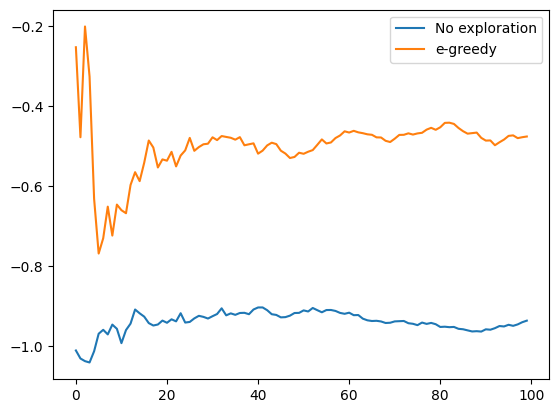

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure()
plt.plot(Data_plot1, label="No exploration")
plt.plot(Data_plot2, label="e-greedy")
plt.legend()
plt.show()